# End-to-end ESM observation ETL and r-GCN training

This notebook demonstrates the missing ETL step: generate/load the aircraft radar KG in Neo4j, generate synthetic ESM observations, compare observations against KG radar modes, write `EvidenceEntity` nodes and candidate edges, then train the r-GCN on those evidence nodes.

Prerequisite: a local Neo4j 5 instance, for example `docker run --rm --name aircraft-kg-neo4j -p 7474:7474 -p 7687:7687 -e NEO4J_AUTH=neo4j/password neo4j:5`.

In [1]:
from pathlib import Path
import json
import os
import sys
import yaml

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "kg_generator.py").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

NEO4J_URI = os.getenv("NEO4J_URI", "bolt://localhost:7687")
NEO4J_USER = os.getenv("NEO4J_USER", "neo4j")
NEO4J_PASSWORD = 'password123'#os.getenv("NEO4J_PASSWORD", "password")
NEO4J_DATABASE = os.getenv("NEO4J_DATABASE", "neo4j")
GENERATED = REPO_ROOT / "generated"
GENERATED.mkdir(exist_ok=True)

## 1. Build and load the aircraft/radar KG

This mirrors `neo4j_kg_creation.ipynb`: constraints are created, typed KG nodes are merged, and relationships are merged by KG `id`.

In [2]:
from neo4j import GraphDatabase
from kg_generator import generate_graph, write_json, write_triples


graph = generate_graph()
write_json(graph, GENERATED / "aircraft_radar_kg.json")
write_triples(graph, GENERATED / "aircraft_radar_triples.csv")

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

def wipe_database(tx):
    tx.run("MATCH (n) DETACH DELETE n")

def create_constraints(tx):
    for statement in [
        "CREATE CONSTRAINT aircraft_family_id IF NOT EXISTS FOR (n:AircraftFamily) REQUIRE n.id IS UNIQUE",
        "CREATE CONSTRAINT aircraft_variant_id IF NOT EXISTS FOR (n:AircraftVariant) REQUIRE n.id IS UNIQUE",
        "CREATE CONSTRAINT radar_id IF NOT EXISTS FOR (n:Radar) REQUIRE n.id IS UNIQUE",
        "CREATE CONSTRAINT radar_mode_id IF NOT EXISTS FOR (n:RadarMode) REQUIRE n.id IS UNIQUE",
        "CREATE CONSTRAINT operator_id IF NOT EXISTS FOR (n:Operator) REQUIRE n.id IS UNIQUE",
    ]:
        tx.run(statement)

def load_nodes(tx, label, rows):
    tx.run(f"""
    UNWIND $rows AS row
    MERGE (n:{label} {{id: row.id}})
    SET n += row.properties
    SET n.id = row.id, n.label = row.label
    """, rows=rows)

def load_edges(tx, relation, rows):
    tx.run(f"""
    UNWIND $rows AS row
    MATCH (source {{id: row.source}})
    MATCH (target {{id: row.target}})
    MERGE (source)-[:{relation}]->(target)
    """, rows=rows)

with driver.session(database=NEO4J_DATABASE) as session:
    session.execute_write(wipe_database)
    session.execute_write(create_constraints)
    labels = sorted({node["label"] for node in graph["nodes"]})
    relations = sorted({edge["relation"] for edge in graph["edges"]})
    for label in labels:
        session.execute_write(load_nodes, label, [node for node in graph["nodes"] if node["label"] == label])
    for relation in relations:
        session.execute_write(load_edges, relation, [edge for edge in graph["edges"] if edge["relation"] == relation])

len(graph["nodes"]), len(graph["edges"])

(458, 566)

## 2. Generate observations

The observations are sampled from the same KG radar-mode bounds, but the ETL treats them as input records and re-scores them against the KG in Neo4j.

In [3]:
from datetime import UTC, datetime
from esm_observation_generator import generate_observations

observations_doc = generate_observations(2500, seed=7, start=datetime(2025, 1, 1, tzinfo=UTC), end=datetime(2025, 2, 1, tzinfo=UTC))
obs_path = GENERATED / "esm_observations_etl_demo.json"
obs_path.write_text(json.dumps(observations_doc, indent=2), encoding="utf-8")
observations_doc["observations"][0]

{'observation_id': 'esm_obs_00001',
 'timestamp_unix': 1735892127,
 'timestamp_iso8601': '2025-01-03T08:15:27Z',
 'sensor': {'type': 'passive_esm',
  'platform': 'synthetic_ground_or_airborne_collector'},
 'estimated_emitter_location': {'area': 'Eastern Mediterranean',
  'estimated_latitude_deg': 33.721989,
  'estimated_longitude_deg': 31.153142,
  'error_box': {'min_latitude_deg': 33.673074,
   'max_latitude_deg': 33.770904,
   'min_longitude_deg': 30.942197,
   'max_longitude_deg': 31.364087}},
 'approximate_kinematics': {'ground_speed_kph': 1397.4,
  'ground_speed_error_kph': 92.0,
  'ground_speed_min_kph': 1305.4,
  'ground_speed_max_kph': 1489.5,
  'altitude_m': 9203.7,
  'altitude_error_m': 149.5,
  'altitude_min_m': 9054.2,
  'altitude_max_m': 9353.2,
  'heading_deg': 210.8,
  'heading_error_deg': 2.9},
 'esm_radar_parameters': {'observed_waveform': 'doppler_filtering',
  'observed_scan_type': 'sector',
  'measured_centre_frequency_ghz': {'value': 9.77983,
   'error': 0.058679,


## 3. Compare observations to KG and create EvidenceEntity graph

`ObservationNeo4jETL` fetches `(Radar)-[:HAS_MODE]->(RadarMode)` rows with optional aircraft/operator context, scores interval overlap and categorical matches, writes observation and candidate `EvidenceEntity` nodes, and creates `HAS_CANDIDATE`, `GROUND_TRUTH_CANDIDATE`, and `SHARES_BEST_MODE` relationships.

In [4]:
from rgcn_fusion.observation_etl import ObservationNeo4jETL, load_observations

etl = ObservationNeo4jETL(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD, NEO4J_DATABASE)
try:
    etl_result = etl.ingest(load_observations(obs_path), max_candidates=5)
finally:
    etl.close()
etl_result

{'observations': 2500,
 'candidates': 12500,
 'candidate_edges': 12500,
 'truth_edges': 771,
 'similarity_edges': 4884}

## 4. Inspect evidence nodes and candidate edges

In [5]:
with driver.session(database=NEO4J_DATABASE) as session:
    rows = session.run("""
    MATCH (obs:Observation)-[r:HAS_CANDIDATE]->(candidate:CandidateEvidence)
    RETURN obs.observation_id AS observation_id, r.rank AS rank, r.score AS score,
           candidate.mode_id AS mode_id, candidate.aircraft_id AS aircraft_id
    ORDER BY observation_id, rank
    LIMIT 10
    """).data()
rows

[{'observation_id': 'esm_obs_00001',
  'rank': 1,
  'score': 0.877598,
  'mode_id': 'radar_mode:zhuk_ae:look_down_shoot_down',
  'aircraft_id': 'aircraft:mig_35'},
 {'observation_id': 'esm_obs_00001',
  'rank': 2,
  'score': 0.877598,
  'mode_id': 'radar_mode:irbis_e:look_down_shoot_down',
  'aircraft_id': 'aircraft:su_35s'},
 {'observation_id': 'esm_obs_00001',
  'rank': 3,
  'score': 0.877598,
  'mode_id': 'radar_mode:irbis_e:look_down_shoot_down',
  'aircraft_id': 'aircraft:su_35s'},
 {'observation_id': 'esm_obs_00001',
  'rank': 4,
  'score': 0.877598,
  'mode_id': 'radar_mode:irbis_e:look_down_shoot_down',
  'aircraft_id': 'aircraft:su_35s'},
 {'observation_id': 'esm_obs_00001',
  'rank': 5,
  'score': 0.877598,
  'mode_id': 'radar_mode:captor_m:look_down_shoot_down',
  'aircraft_id': 'aircraft:typhoon_tranche_1'},
 {'observation_id': 'esm_obs_00002',
  'rank': 1,
  'score': 0.871051,
  'mode_id': 'radar_mode:n019_rubin:air_to_ground_mapping',
  'aircraft_id': 'aircraft:mig_29a'},

## 5. Train the r-GCN on the EvidenceEntity subgraph

The training config points `Neo4jGraphLoader` at `EvidenceEntity` nodes. The model uses the ETL-produced `degree_score`, `text_score`, and `recency_score` features plus the ETL-produced DS masses. It also trains categorical diagnostic heads for aircraft type, aircraft variant, radar mode, radar type, and operator country using ETL/KG labels carried on each `EvidenceEntity`.

This run intentionally mirrors `rgcn_dempster_shafer_identification_demo.ipynb`: the neural net uses a seeded 50%/30%/20% train/test/validation split, writes TensorBoard progress diagnostics, checkpoints the best validation-loss model, prints epoch-by-epoch train/test losses and accuracies, and displays a train/test metrics plot when fitting completes.

TensorBoard event files are written under `artifacts/observation_etl_demo/tensorboard`. In Jupyter, run `%load_ext tensorboard` and `%tensorboard --logdir <that path>` to examine losses, train/test/validation accuracies, and learning rate while or after training.


### Optional TensorBoard viewer

Run this cell in Jupyter to open the live TensorBoard dashboard for this training run.


In [6]:
%load_ext tensorboard
%tensorboard --logdir ../artifacts/observation_etl_demo/tensorboard


Reusing TensorBoard on port 6006 (pid 6588), started 16:20:52 ago. (Use '!kill 6588' to kill it.)

TensorBoard log directory: C:\Users\theon\r-GCN_fusion\artifacts\observation_etl_demo\tensorboard
{'train': 7500, 'test': 4500, 'val': 3000}
Training r-GCN: starting (250 steps)
epoch=0001 | train_loss=24.383543 | test_loss=24.391304 | val_loss=24.379997 | train_mass_loss=0.429536 | test_mass_loss=0.428106 | train_classification_loss=23.954006 | test_classification_loss=23.963198 | train_aircraft_type_acc=0.1120 | test_aircraft_type_acc=0.1213 | train_aircraft_variant_acc=0.0112 | test_aircraft_variant_acc=0.0109 | train_radar_mode_acc=0.0003 | test_radar_mode_acc=0.0002 | train_radar_type_acc=0.0028 | test_radar_type_acc=0.0029 | train_operator_country_acc=0.0183 | test_operator_country_acc=0.0202
epoch=0002 | train_loss=22.540516 | test_loss=22.557056 | val_loss=22.534050 | train_mass_loss=0.209942 | test_mass_loss=0.209613 | train_classification_loss=22.330574 | test_classification_loss=22.347443 | train_aircraft_type_acc=0.1533 | test_aircraft_type_acc=0.1629 | train_aircraft_varia

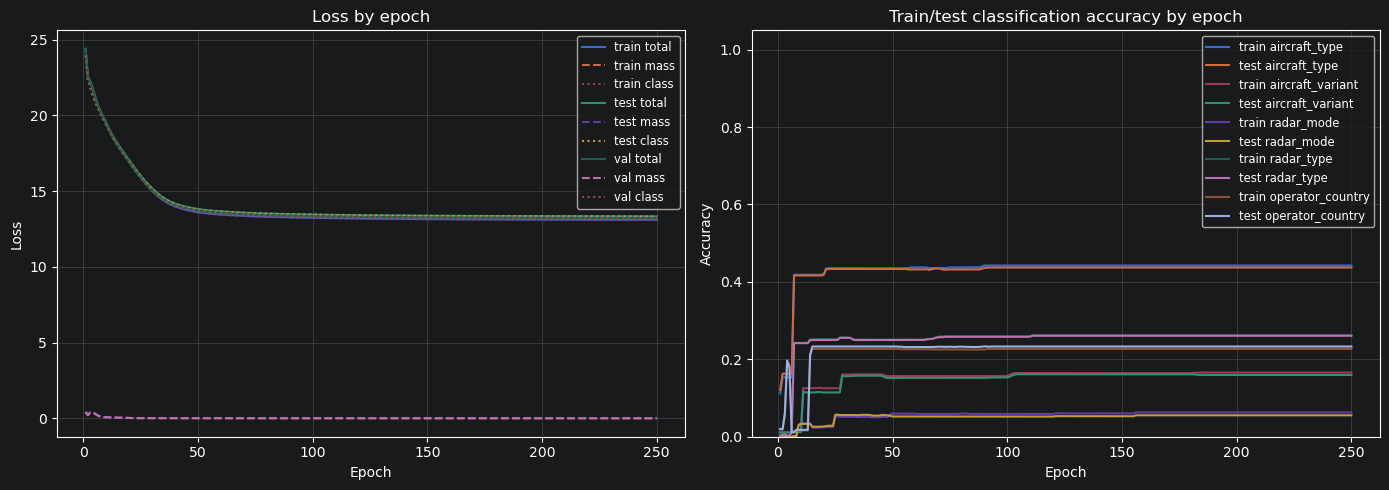

{'output_dir': 'C:\\Users\\theon\\r-GCN_fusion\\artifacts\\observation_etl_demo',
 'final_loss': 13.224750518798828,
 'nodes': 15000,
 'classification_tasks': ['aircraft_type',
  'aircraft_variant',
  'radar_mode',
  'radar_type',
  'operator_country']}

In [7]:
observation_etl_rgcn_end_to_end.ipynbfrom rgcn_fusion.train import train_model

TENSORBOARD_LOG_DIR = REPO_ROOT / "artifacts" / "observation_etl_demo" / "tensorboard"
print(f"TensorBoard log directory: {TENSORBOARD_LOG_DIR}")

SEED = 42
TRAIN_FRACTION = 0.5
TEST_FRACTION = 0.3
VAL_FRACTION = 0.2
assert abs(TRAIN_FRACTION + TEST_FRACTION + VAL_FRACTION - 1.0) < 1e-9

train_config = {
    "neo4j": {"uri": NEO4J_URI, "user": NEO4J_USER, "password": NEO4J_PASSWORD, "database": NEO4J_DATABASE},
    "data": {
        "hypotheses": ["non_match", "match"],
        "feature_properties": ["degree_score", "text_score", "recency_score"],
        "label_property": "ds_masses",
        "classification": True,
        "classification_label_properties": {
            "aircraft_type": "aircraft_type",
            "aircraft_variant": "aircraft_id",
            "radar_mode": "mode_id",
            "radar_type": "radar_id",
            "operator_country": "operator_country",
        },
        "node_query": """
        MATCH (n:EvidenceEntity)
        OPTIONAL MATCH (aircraft:AircraftVariant {id: n.aircraft_id})-[:VARIANT_OF]->(family:AircraftFamily)
        WITH n, n {.*, aircraft_type: coalesce(family.id, n.aircraft_id), operator_country: n.operator} AS props
        RETURN elementId(n) AS id, props
        ORDER BY id
        """,
        "edge_query": """
        MATCH (s:EvidenceEntity)-[r]->(t:EvidenceEntity)
        RETURN elementId(s) AS source, elementId(t) AS target, type(r) AS type
        ORDER BY source, target, type
        """,
    },
    "model": {"hidden_features": 32, "dropout": 0.1},
    "training": {
        "epochs": 250,
        "learning_rate": 0.001,
        "weight_decay": 0.0001,
        "device": "cpu",
        "seed": SEED,
        "train_fraction": TRAIN_FRACTION,
        "test_fraction": TEST_FRACTION,
        "val_fraction": VAL_FRACTION,
        "patience": 30,
    },
    "output": {"directory": str(REPO_ROOT / "artifacts" / "observation_etl_demo")},
}
result = train_model(train_config)
result

## 6. Inspect model output

In [8]:
output_path = Path(train_config["output"]["directory"]) / "node_evidence.json"
node_evidence = json.loads(output_path.read_text(encoding="utf-8"))
node_evidence[:3]

[{'node_id': '4:a2f0e948-96da-4db5-bfd9-01d1aa04cbc9:0',
  'masses': [0.05393534153699875, 0.34861400723457336, 0.5974506735801697],
  'uncertainty': None,
  'intervals': [{'hypothesis': 'non_match',
    'belief': 0.05393534033144995,
    'plausibility': 0.6513860005575568},
   {'hypothesis': 'match',
    'belief': 0.34861399944244326,
    'plausibility': 0.94606465966855}],
  'classifications': {'aircraft_type': {'label': 'aircraft_family:mig_29',
    'probability': 0.09890318661928177,
    'probabilities': [0.015618723817169666,
     0.007064971141517162,
     0.010748367756605148,
     0.010033211670815945,
     0.01717527024447918,
     0.009210104122757912,
     0.06461554765701294,
     0.04922766610980034,
     0.020812639966607094,
     0.04616542160511017,
     0.04626283794641495,
     0.04114871844649315,
     0.019046256318688393,
     0.04004604369401932,
     0.01867268979549408,
     0.024811498820781708,
     0.01818353869020939,
     0.010704636573791504,
     0.013658

In [ ]:
driver.close()